In [1]:
import pandas as pd
import mysql.connector
import os

# List of CSV files and their corresponding table names
csv_files = [
    ('Customers.csv', 'Customers'),
    ('Copy of EverMart_Online_Transactions.csv', 'Online_transactions'),
    ('Transactions.csv', 'Transactions'),
    ('Products.csv', 'Products')  
]

# Connect to the MySQL database
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='24ds09',
    database='ecommerce'
)
cursor = conn.cursor()

# Folder containing the CSV files
folder_path = 'C:/Users/Aliab/Desktop/New folder/new project'

def get_sql_type(dtype):
    if pd.api.types.is_integer_dtype(dtype):
        return 'INT'
    elif pd.api.types.is_float_dtype(dtype):
        return 'FLOAT'
    elif pd.api.types.is_bool_dtype(dtype):
        return 'BOOLEAN'
    elif pd.api.types.is_datetime64_any_dtype(dtype):
        return 'DATETIME'
    else:
        return 'TEXT'

for csv_file, table_name in csv_files:
    file_path = os.path.join(folder_path, csv_file)
    
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(file_path)
    
    # Replace NaN with None to handle SQL NULL
    df = df.where(pd.notnull(df), None)
    
    # Debugging: Check for NaN values
    print(f"Processing {csv_file}")
    print(f"NaN values before replacement:\n{df.isnull().sum()}\n")

    # Clean column names
    df.columns = [col.replace(' ', '_').replace('-', '_').replace('.', '_') for col in df.columns]

    # Generate the CREATE TABLE statement with appropriate data types
    columns = ', '.join([f'`{col}` {get_sql_type(df[col].dtype)}' for col in df.columns])
    create_table_query = f'CREATE TABLE IF NOT EXISTS `{table_name}` ({columns})'
    cursor.execute(create_table_query)

    # Insert DataFrame data into the MySQL table
    for _, row in df.iterrows():
        # Convert row to tuple and handle NaN/None explicitly
        values = tuple(None if pd.isna(x) else x for x in row)
        sql = f"INSERT INTO `{table_name}` ({', '.join(['`' + col + '`' for col in df.columns])}) VALUES ({', '.join(['%s'] * len(row))})"
        cursor.execute(sql, values)

    # Commit the transaction for the current CSV file
    conn.commit()

# Close the connection
conn.close()

Processing Customers.csv
NaN values before replacement:
CustomerID      0
CustomerName    0
Region          0
SignupDate      0
dtype: int64

Processing Copy of EverMart_Online_Transactions.csv
NaN values before replacement:
TransactionID      0
CustomerID         0
ProductID          0
TransactionDate    0
Quantity           0
TotalValue         0
Price              0
dtype: int64

Processing Transactions.csv
NaN values before replacement:
TransactionID      0
CustomerID         0
ProductID          0
TransactionDate    0
Quantity           0
TotalValue         0
Price              0
dtype: int64

Processing Products.csv
NaN values before replacement:
ProductID      0
ProductName    0
Category       0
Price          0
dtype: int64



In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector
import warnings
warnings.filterwarnings('ignore')


db = mysql.connector.connect(host = "localhost", 
                             username = "root", 
                             password = "24ds09", 
                             database = "ecommerce")

cur = db.cursor()

## What is the total revenue generated?

In [3]:
query = 'select round(sum(TotalValue), 2) from transactions'

cur.execute(query)

data = cur.fetchall()

data

[(8969942.27,)]

### How many total transactions are there?

In [4]:
query = 'select count(TransactionID) from transactions'

cur.execute(query)

data = cur.fetchall()

"Total number of transactions: ",data

('Total number of transactions: ', [(13000,)])

###  What is the total quantity of products sold? 

In [5]:
query = 'select sum(Quantity) from transactions'

cur.execute(query)

data = cur.fetchall()

data

[(Decimal('32981'),)]

### What is the average transactions value?

In [6]:
query = 'select round(avg(TotalValue),2) from transactions '

cur.execute(query)

data = cur.fetchall()

data

[(690.0,)]

### Which region has the Highest number of Customers?

In [7]:
query = """ select Region, count(CustomerID) as TotalCustomers from customers
group by Region order by TotalCustomers desc limit 1"""

cur.execute(query)

data = cur.fetchall()

data

[('South America', 767)]

### What are the top 10 customers by total spending, and how do they compare visually?

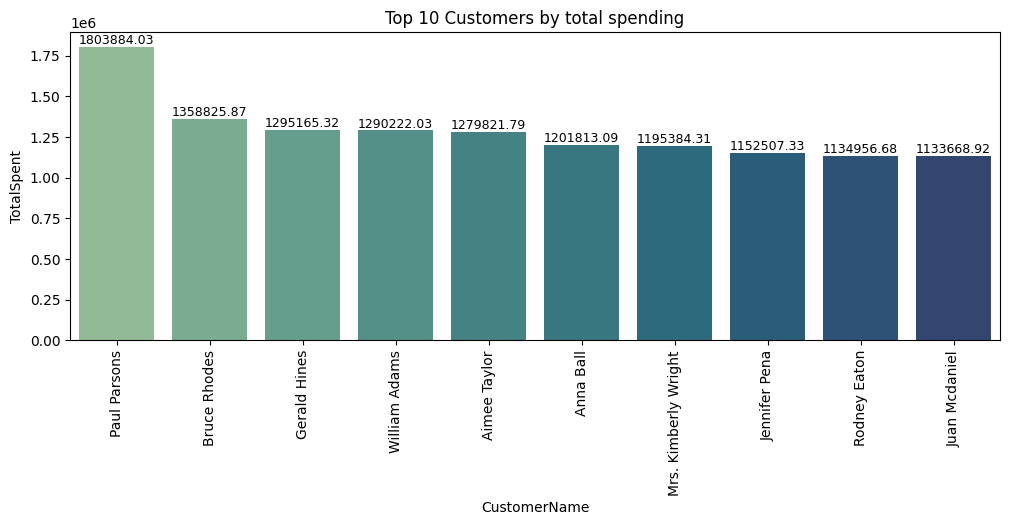

In [40]:
query = """ select c.CustomerName, round(sum(t.TotalValue), 2) as TotalSpent from transactions as t
join customers as c
on c.CustomerID = t.CustomerID
group by CustomerName order by TotalSpent desc limit 10
 """

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['CustomerName','TotalSpent'])

plt.figure(figsize=(12,4))
ax = sns.barplot(df, x='CustomerName', y='TotalSpent', palette='crest')
plt.title('Top 10 Customers by total spending')
plt.xticks(rotation = 90)

for container in ax.containers:
    ax.bar_label(container, size=9, fmt='%.2f')

plt.show()    

### What are the top 10 products by revenue?

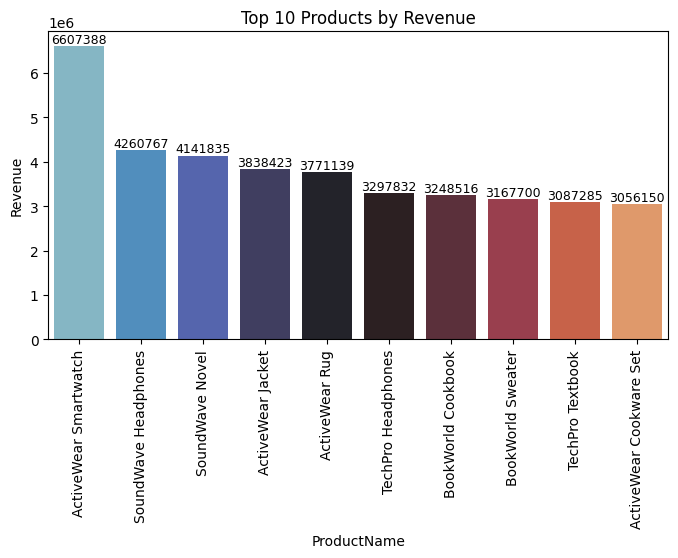

In [9]:
query = """ select p.ProductName, round(sum(t.TotalValue), 2) as Revenue from transactions as t
join products as p
on t.ProductID = p.ProductID 
group by p.ProductName order by Revenue desc limit 10
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['ProductName', 'Revenue'])

plt.figure(figsize=(8,4))
ax = sns.barplot(df, x='ProductName', y='Revenue', palette='icefire')
plt.title('Top 10 Products by Revenue')
plt.xticks(rotation = 90)

for container in ax.containers:
    ax.bar_label(container, size=9, fmt='%.0f')

plt.show()    

### What is the average transaction value by each region?

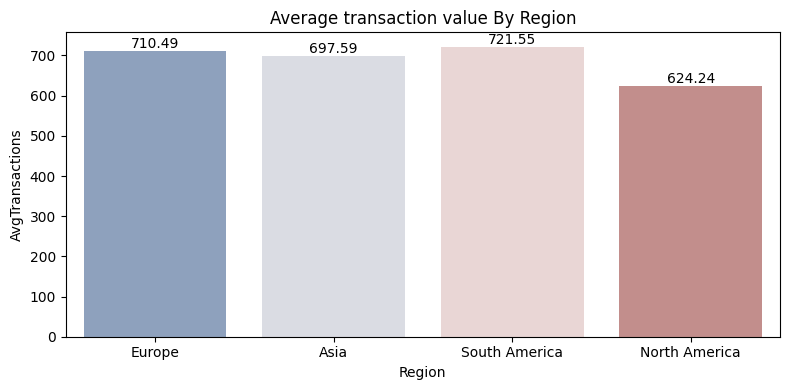

In [10]:
query = """ select c.Region, round(avg(t.TotalValue),2) as AvgTransactions from customers as c 
join transactions as t 
on c.CustomerID = t.CustomerID 
group by c.Region """

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['Region', 'AvgTransactions'])

plt.figure(figsize=(8,4))
ax = sns.barplot(df, x='Region', y='AvgTransactions', palette='vlag')
plt.title('Average transaction value By Region')

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show() 

### What is the total revenue generated by each product category?

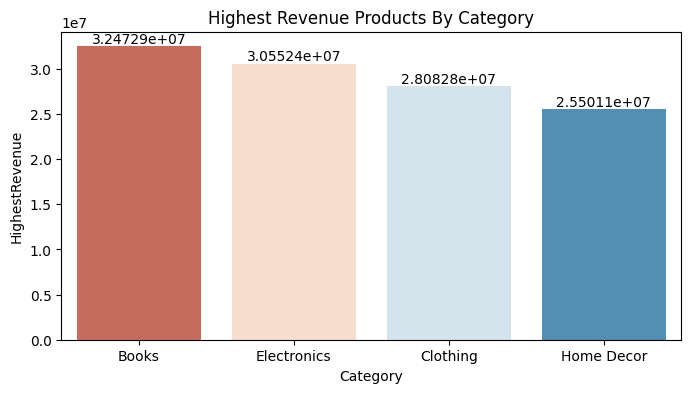

In [11]:
query = """ select p.Category, round(sum(t.TotalValue), 2) as HighestRevenue from products as p
join transactions as t
on p.ProductID = t.ProductID
group by p.Category order by HighestRevenue desc """

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['Category', 'HighestRevenue'])

plt.figure(figsize=(8,4))
ax = sns.barplot(df, x='Category', y='HighestRevenue', palette='RdBu')
plt.title('Highest Revenue Products By Category')

for container in ax.containers:
    ax.bar_label(container)

plt.show()    

### What is the Quantity Sold by each product category?

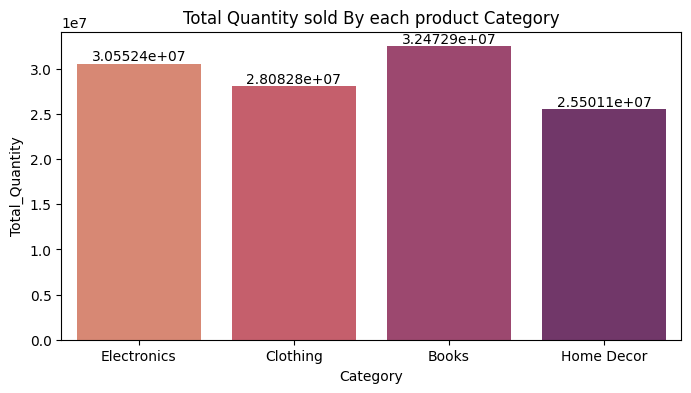

In [12]:
query = """ select p.Category, sum(t.TotalValue) as Total_Quantity from products p
join transactions t
on p.ProductID = t.ProductID 
group by p.Category """

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['Category', 'Total_Quantity'])

plt.figure(figsize=(8,4))
ax = sns.barplot(df, x='Category', y='Total_Quantity', palette='flare')
plt.title('Total Quantity sold By each product Category')

for container in ax.containers:
    ax.bar_label(container)

plt.show() 

### How many unique customers purchased each product category?

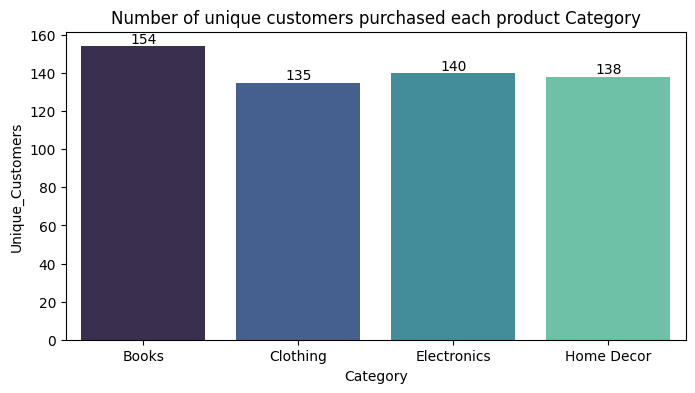

In [13]:
query = """ select p.Category, count(distinct(t.CustomerID)) as cutomers from products p
join transactions t
on t.ProductID = p.ProductID
group by p.Category """

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['Category', 'Unique_Customers'])

plt.figure(figsize=(8,4))
ax = sns.barplot(df, x='Category', y='Unique_Customers', palette='mako')
plt.title('Number of unique customers purchased each product Category')

for container in ax.containers:
    ax.bar_label(container)

plt.show() 

### How many unique products has eash customer purchased?

In [14]:
query = """ select c.CustomerName, count(distinct(t.ProductID)) as UniqueProducts from transactions t
join customers c 
on c.CustomerID = t.CustomerID
group by CustomerName order by UniqueProducts desc """

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['CustomerName', 'UniqueProductsPurchased'])

df

,CustomerName,UniqueProductsPurchased
0,Abigail Jones,10
1,David Li,10
2,Gerald Hines,10
3,Matthew Johnson,10
4,Paul Parsons,10
...,...,...
194,Mr. Manuel Conway,1
195,Robert Jones,1
196,Tina Ford,1
197,Tyler Holt,1


### What is the total spending and average transaction value for each customer?

In [15]:
query = """ select c.CustomerName, round(sum(t.TotalValue), 2), round(avg(t.TotalValue), 2) from transactions t
join customers c
on c.CustomerID = t.CustomerID
group by CustomerName """

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['CustomerName', 'TotalSpending', 'AverageTransaction'])

df

,CustomerName,TotalSpending,AverageTransaction
0,Andrea Jenkins,334498.31,494.82
1,Brittany Harvey,434465.20,642.70
2,Kathryn Stevens,546356.72,538.81
3,Travis Campbell,1116114.87,943.46
4,Timothy Perez,528207.80,781.37
...,...,...,...
194,Zachary Turner,66981.46,396.34
195,William Walker,217041.63,642.13
196,Amber Gonzalez,37849.24,223.96
197,Julia Palmer,168242.88,995.52


### What are the top 3 products by revenue within each category?

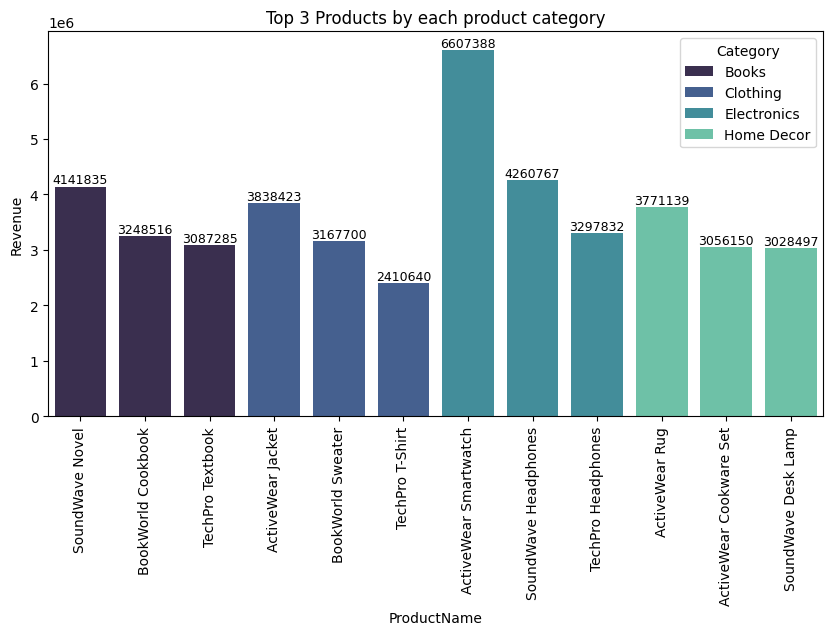

In [16]:
query = """ select * from (select p.Category, p.ProductName, round(sum(t.TotalValue)) as total_sales,
row_number() over(
partition by p.Category
order by sum(t.TotalValue) desc)
as rn
from products p
join transactions t
on p.ProductID = t.ProductID
group by p.Category,p.ProductName
) x
where rn <=3 """

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['Category', 'ProductName', 'Revenue', 'RowNumber'])

plt.figure(figsize=(10,5))
ax = sns.barplot(df, x='ProductName', y='Revenue', hue='Category', palette='mako')
plt.title('Top 3 Products by each product category')
plt.xticks(rotation = 90)

for container in ax.containers:
    ax.bar_label(container, size=9, fmt='%.0f')

plt.show()    

### Which product category is most popular in each region?

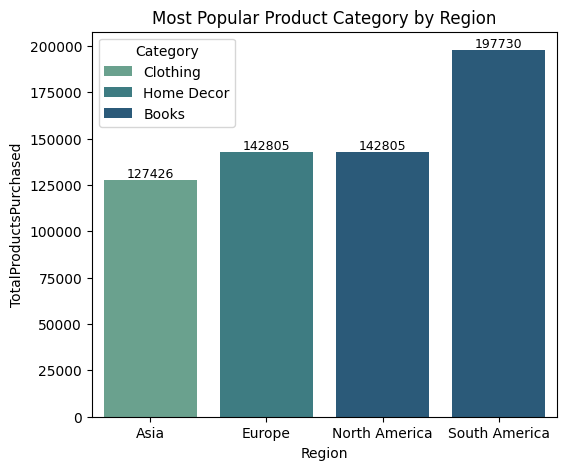

In [17]:
query = """ select * from (select c.Region, p.Category, count(t.ProductID) as TotalProductsPurchased,
row_number() over(
partition by c.Region
order by count(t.ProductID) desc
) as rn
from transactions t
join customers c
on c.CustomerID = t.CustomerID
join products p
on p.ProductID = t.ProductID
group by Region, Category
) x
where rn <= 1 """

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['Region', 'Category', 'TotalProductsPurchased', 'RowNumber'])

plt.figure(figsize=(6,5))
ax = sns.barplot(df, x='Region', y='TotalProductsPurchased', hue='Category', palette='crest')
plt.title('Most Popular Product Category by Region')

for container in ax.containers:
    ax.bar_label(container, size=9, fmt='%.0f')

plt.show()    

### Which region generates the highest revenue for each product category?

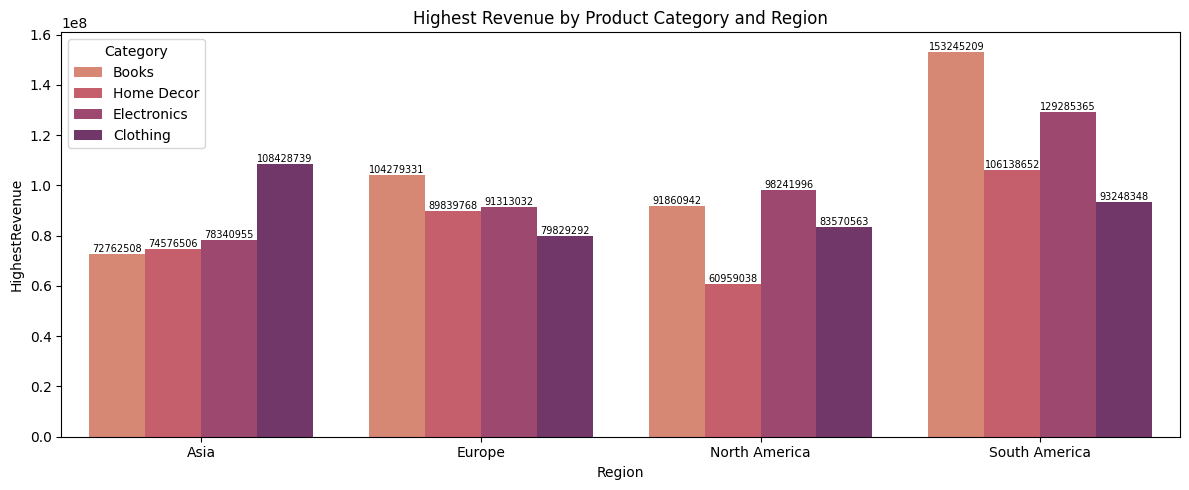

In [18]:
query = """ select * from (select c.Region, p.Category, round(sum(t.TotalValue)) as Revenue,
row_number() over(
partition by c.Region
order by sum(t.TotalValue)
) rn
from transactions t
join customers c
on c.CustomerID = t.CustomerID
join products p
on p.ProductID = t.ProductID
group by Category,Region
) x
"""
cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['Region', 'Category', 'HighestRevenue', 'RowNumber'])

plt.figure(figsize=(12,5))
ax = sns.barplot(df, x='Region', y='HighestRevenue', hue='Category', palette='flare')
plt.title('Highest Revenue by Product Category and Region')

for container in ax.containers:
    ax.bar_label(container, size=7, fmt='%.0f')

plt.tight_layout()
plt.show()    

### What percentage of total revenue comes from each product category?

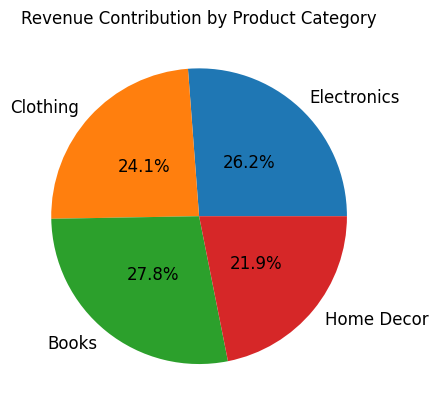

In [19]:
query = """ select p.Category, round(sum(t.TotalValue) * 100 / sum(sum(t.TotalValue)) over(),2) as percentage from transactions t
join products p 
on p.ProductID = t.ProductID
group by p.Category 
"""
cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['Category', 'Percentage'])

ax = plt.pie(df['Percentage'], labels=df['Category'], autopct='%.1f%%', textprops={'fontsize':12}, pctdistance=0.5)
plt.title('Revenue Contribution by Product Category')

plt.show()    

### What is the monthly revenue trend?

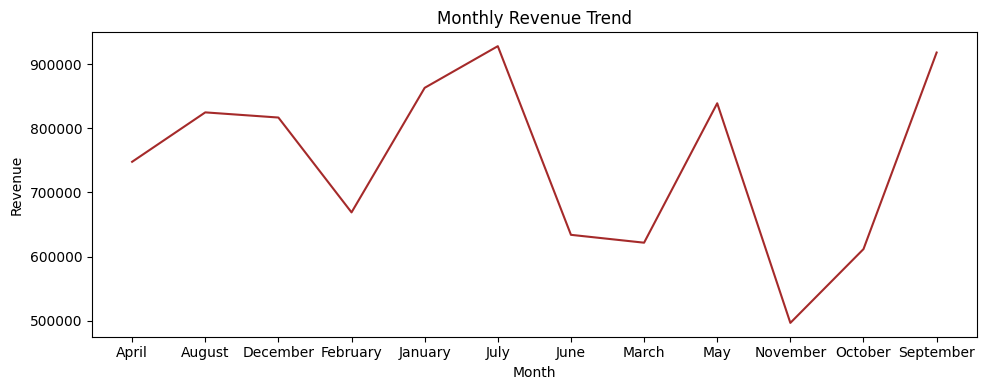

In [20]:
query = """ select monthname(TransactionDate) as Month, round(sum(TotalValue),2) as Revenue from transactions
group by Month
order by Month asc""" 

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['Month', 'Revenue'])

plt.figure(figsize=(10,4))
ax = sns.lineplot(df, x='Month', y='Revenue', color='brown')
plt.title('Monthly Revenue Trend')

plt.tight_layout()
plt.show()

### How many transactions occur each month?

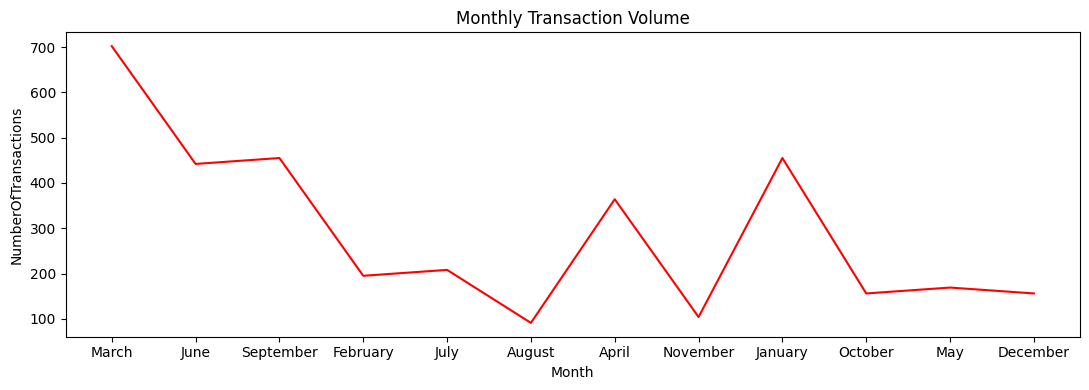

In [21]:
query = """ select monthname(TotalValue) Month, count(TransactionID) from transactions 
group by Month 
"""
cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['Month', 'NumberOfTransactions'])

plt.figure(figsize=(11,4))
ax = sns.lineplot(df, x='Month', y='NumberOfTransactions', color='r')
plt.title('Monthly Transaction Volume')

plt.tight_layout()
plt.show()

### Which month generated the highest revenue?

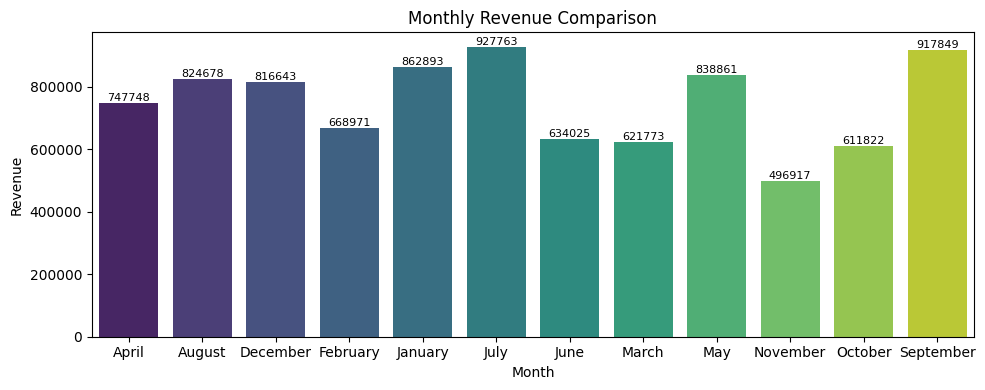

In [22]:
query = """ select monthname(TransactionDate) as Month, round(sum(TotalValue),2) as Revenue from transactions
group by Month
order by Month asc""" 

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['Month', 'Revenue'])

plt.figure(figsize=(10,4))
ax = sns.barplot(df, x='Month', y='Revenue', palette='viridis')
plt.title('Monthly Revenue Comparison')

for container in ax.containers:
    ax.bar_label(container, size=8)
    
plt.tight_layout()
plt.show()

### Which month had the highest number of transactions?

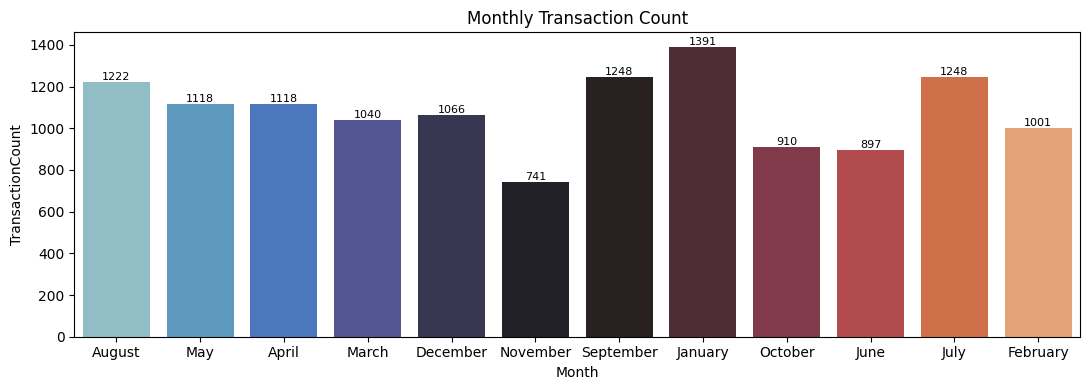

In [23]:
query = """ select monthname(TransactionDate) Month, count(CustomerID) from transactions
group by Month """

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['Month', 'TransactionCount'])

plt.figure(figsize=(11,4))
ax = sns.barplot(df, x='Month', y='TransactionCount', palette='icefire')
plt.title('Monthly Transaction Count')

for container in ax.containers:
    ax.bar_label(container, size=8)

plt.tight_layout()
plt.show()    

### How does revenue compare between 2023 and 2024?

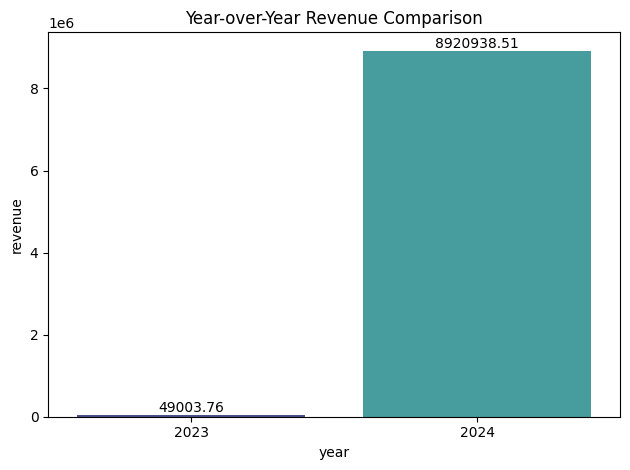

In [24]:
query = """ select year(TransactionDate) as year, round(sum(TotalValue), 2) as revenue
from transactions 
group by year
order by year
 """

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['year', 'revenue'])

ax = sns.barplot(df, x='year', y='revenue', palette='mako')
plt.title('Year-over-Year Revenue Comparison')

for container in ax.containers:
    ax.bar_label(container, size=10, fmt='%.2f')

plt.tight_layout()
plt.show()    

### What is the quarterly revenue trend?

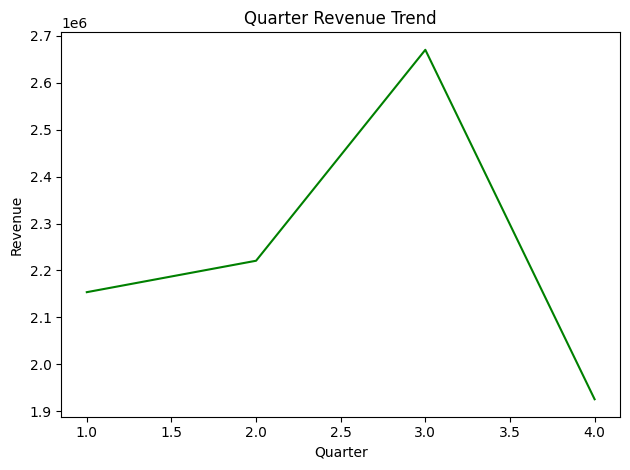

In [25]:
query = """ select quarter(TransactionDate) as quarter, round(sum(TotalValue), 2) as revenue
from transactions 
group by quarter
order by quarter
 """

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['Quarter', 'Revenue'])

ax = sns.lineplot(df, x='Quarter', y='Revenue', color='g')
plt.title('Quarter Revenue Trend')

plt.tight_layout()
plt.show()  

### Which quarter generates the highest revenue?

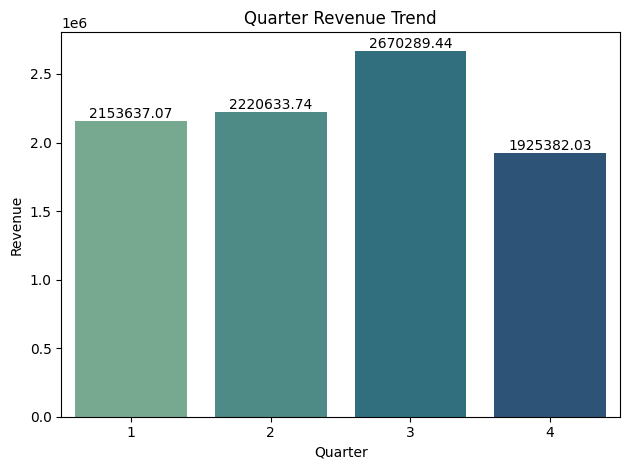

In [26]:
query = """ select quarter(TransactionDate) as quarter, round(sum(TotalValue), 2) as revenue
from transactions 
group by quarter
order by quarter
 """

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['Quarter', 'Revenue'])

ax = sns.barplot(df, x='Quarter', y='Revenue', palette='crest')
plt.title('Quarter Revenue Trend')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.show() 

### Which Day of the week has the highest sales?

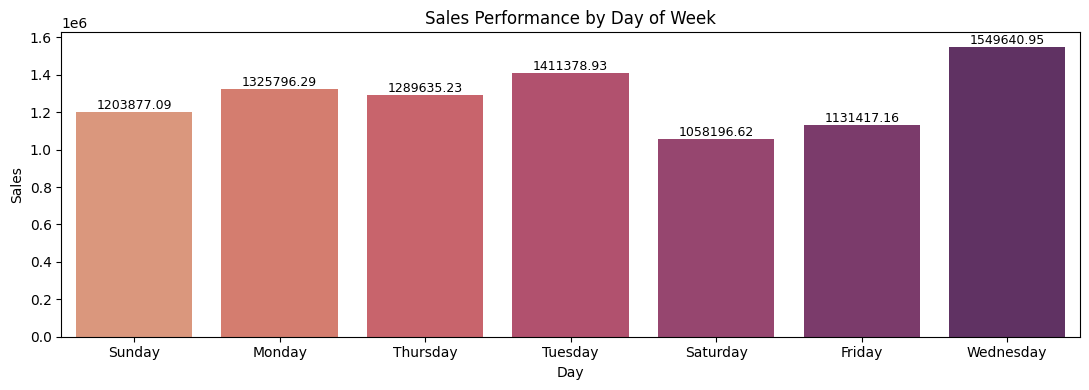

In [27]:
query = """ select dayname(TransactionDate) as Day, round(sum(TotalValue),2) as Sales
from transactions 
group by Day
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['Day', 'Sales'])

plt.figure(figsize=(11,4))
ax = sns.barplot(df, x='Day', y='Sales', palette='flare')
plt.title('Sales Performance by Day of Week')

for container in ax.containers:
    ax.bar_label(container, size=9, fmt='%.2f')

plt.tight_layout()
plt.show()    

### Is there a noticeable upward or downward trend in revenue over time?

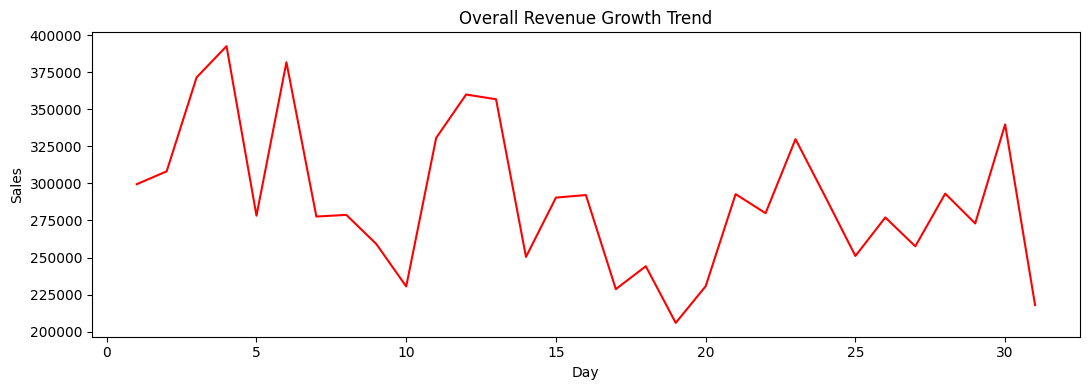

In [28]:
query = """ select day(TransactionDate) as Day, round(sum(TotalValue),2) as Sales
from transactions 
group by Day
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['Day', 'Sales'])

plt.figure(figsize=(11,4))
ax = sns.lineplot(df, x='Day', y='Sales', color='r')
plt.title('Overall Revenue Growth Trend')

plt.tight_layout()
plt.show()    

### How many customers have made only one purchase?

In [29]:
query = """ select c.CustomerName, count(t.CustomerID) as customer_count from transactions t
join customers c
on c.CustomerID = t.CustomerID
group by c.CustomerName 
having customer_count = 1
"""

cur.execute(query)

data = cur.fetchall()

"No customers have made only a single purchase here",data

('No customers have made only a single purchase here', [])

### What is the repeat purchase count per customer?

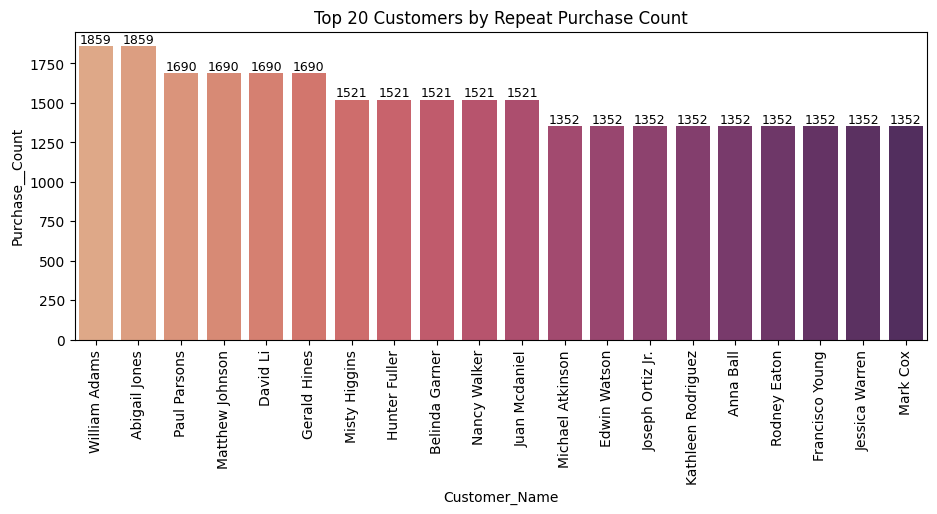

In [69]:
query = """ select c.CustomerName, count(t.TransactionID) as customer_count from transactions t
join customers c
on c.CustomerID = t.CustomerID
group by c.CustomerName 
order by customer_count desc
limit 20
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['Customer_Name', 'Purchase__Count'])

plt.figure(figsize=(11,4))
ax = sns.barplot(df, x='Customer_Name', y='Purchase__Count', palette='flare')
plt.title('Top 20 Customers by Repeat Purchase Count')
plt.xticks(rotation=90)

for container in ax.containers:
    ax.bar_label(container, size=9, fmt='%.f')


plt.show()    

### Who are the highest-value customers?

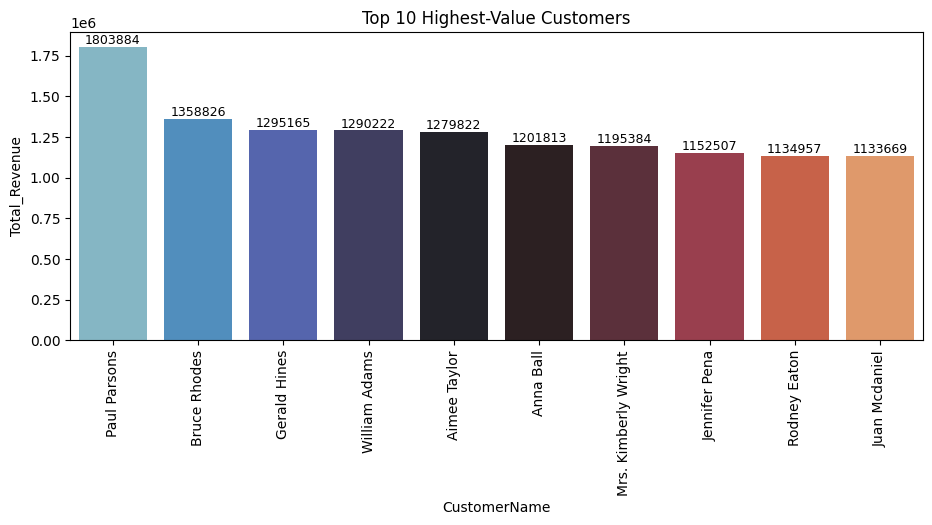

In [44]:
query = """ select c.CustomerName, round(sum(t.TotalValue), 2) as revenue from transactions t
join customers c
on c.CustomerID = t.CustomerID
group by CustomerName 
order by revenue desc
limit 10"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=['CustomerName', 'Total_Revenue'])

plt.figure(figsize=(11,4))
ax = sns.barplot(df, x='CustomerName', y='Total_Revenue', palette='icefire')
plt.title('Top 10 Highest-Value Customers')
plt.xticks(rotation=90)

for container in ax.containers:
    ax.bar_label(container, size=9, fmt='%.f')

plt.show()   

### What is the average number of transactions per customer?

In [68]:
query = """ with customer_transactions as (
select CustomerID, count(TransactionID) as transaction_count from transactions 
group by CustomerID
)
select round(avg(transaction_count),2) from customer_transactions"""

cur.execute(query)

data = cur.fetchall()

print(f"Average transaction per customer is :{data[0][0]}")

Average transaction per customer is :65.33


### What is the average quantity per transaction?

In [75]:
query = """ select round((sum(Quantity) / count(TransactionID)),2) from transactions"""

cur.execute(query)

data = cur.fetchall()

print(f"Average Quantity Per Transaction : {data[0][0]}")

Average Quantity Per Transaction : 2.54


### Is product price related to revenue?

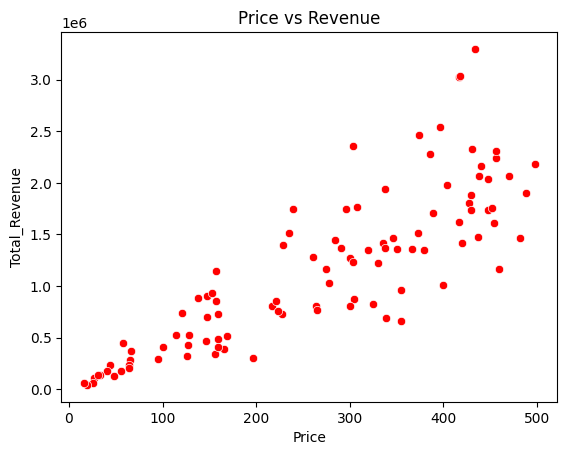

In [80]:
query = """ select p.ProductID, p.ProductName, p.Price, sum(t.TotalValue) as total_revenue
from products p
join transactions t
on p.ProductID = t.ProductID
group by p.ProductID, p.ProductName, p.Price """

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns = ['ProductID', 'ProductName', 'Price', 'Total_Revenue'])

ax = sns.scatterplot(df, x='Price', y='Total_Revenue', color='r')
plt.title('Price vs Revenue')

plt.show()  

### Is sales Quantity related to revenue?

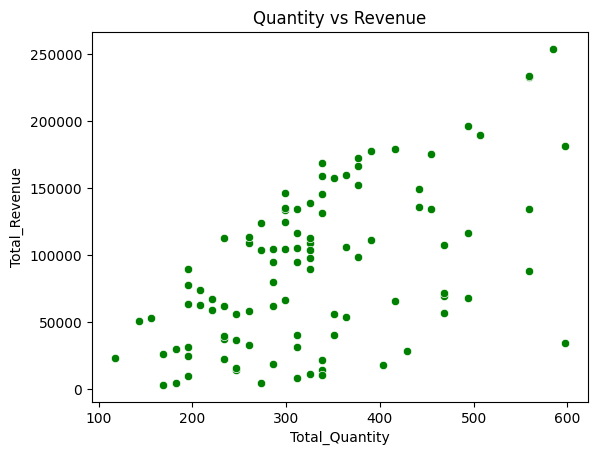

In [92]:
query = """ select ProductID, sum(Quantity), sum(TotalValue) as total_revenue
from transactions 
group by ProductID
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns = ['ProductID', 'Total_Quantity', 'Total_Revenue'])

ax = sns.scatterplot(df, x='Total_Quantity', y='Total_Revenue', color='g')
plt.title('Quantity vs Revenue')

plt.show()  